In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv



# IRRIGATION NEED PREDICTION - COMPLETE KAGGLE ML PIPELINE
# Target: Irrigation_Need (Low / Medium / High)
# Metric: Balanced Accuracy
 

In [2]:
TRAIN_PATH = "/kaggle/input/competitions/playground-series-s6e4/train.csv"          
TEST_PATH  = "/kaggle/input/competitions/playground-series-s6e4/test.csv"          
OUTPUT_PATH = "/kaggle/working/submission.csv"

import warnings, random, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

TARGET      = "Irrigation_Need"
N_FOLDS     = 5
N_OPTUNA    = 50

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
#  1. LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("  1. LOADING DATA")
print("=" * 70)

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# preserve test IDs
if "id" in test.columns:
    test_ids = test["id"]
else:
    test_ids = pd.Series(range(len(test)), name="id")

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print(f"\nTarget distribution:\n{train[TARGET].value_counts()}")


  1. LOADING DATA
Train shape : (630000, 21)
Test  shape : (270000, 20)

Target distribution:
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64



  2. EDA

── Dtypes & Nulls ──
No missing values ✓

── Numeric Summary ──
                            count           mean            std    min          25%        50%        75%        max
id                       630000.0  314999.500000  181865.479132   0.00  157499.7500  314999.50  472499.25  629999.00
Soil_pH                  630000.0       6.482497       0.922504   4.80       5.6900       6.44       7.27       8.20
Soil_Moisture            630000.0      37.304482      16.377082   8.00      23.3400      37.75      51.27      64.99
Organic_Carbon           630000.0       0.922858       0.365808   0.30       0.6100       0.91       1.22       1.60
Electrical_Conductivity  630000.0       1.744605       0.952321   0.10       0.9300       1.74       2.58       3.50
Temperature_C            630000.0      26.998166       8.623621  12.00      19.5175      26.96      34.54      42.00
Humidity                 630000.0      61.563180      19.708152  25.00      45.3900      61.65      79.12 

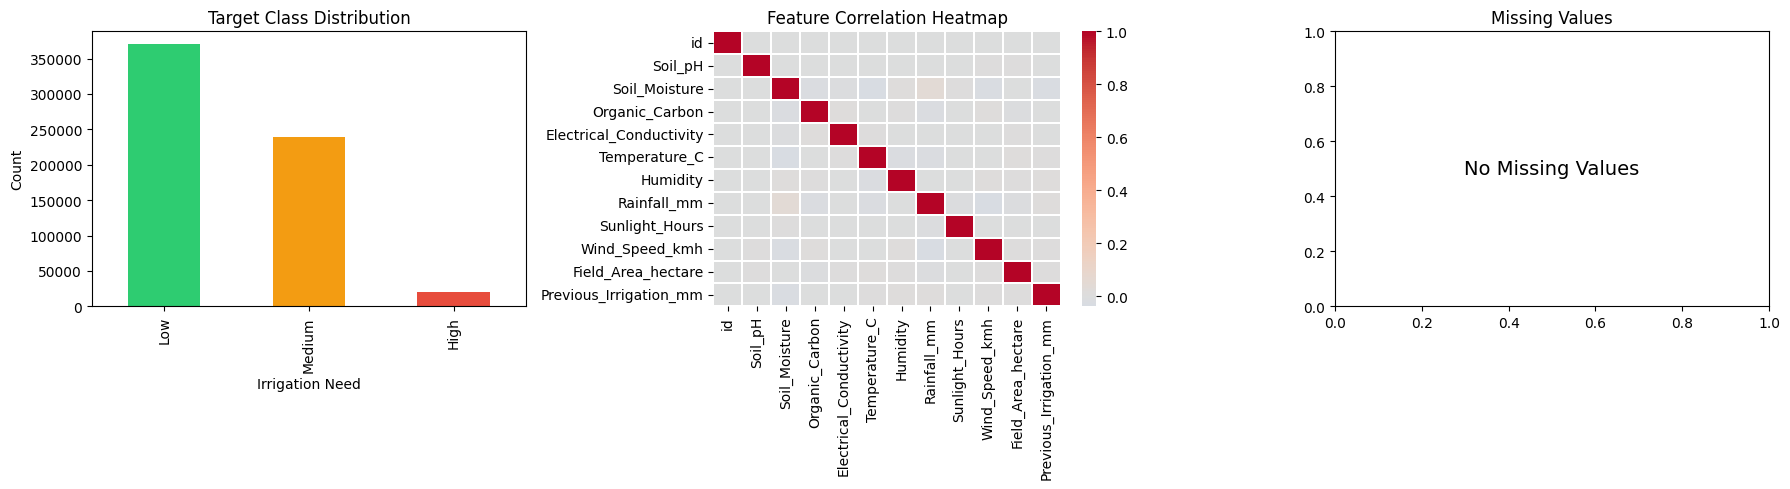

EDA plot saved → eda_overview.png


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
#  2. EXPLORATORY DATA ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  2. EDA")
print("=" * 70)

# --- Basic info ---
print("\n── Dtypes & Nulls ──")
info_df = pd.DataFrame({
    "dtype":   train.dtypes,
    "nulls":   train.isnull().sum(),
    "null_%":  (train.isnull().mean() * 100).round(2),
    "nunique": train.nunique()
})
print(info_df[info_df["nulls"] > 0] if info_df["nulls"].sum() > 0 else "No missing values ✓")

# --- Numeric summary ---
print("\n── Numeric Summary ──")
print(train.describe().T.to_string())

# --- Class imbalance ---
class_counts = train[TARGET].value_counts()
print(f"\n── Class Balance ──\n{class_counts}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
class_counts.plot(kind="bar", ax=axes[0], color=["#2ecc71","#f39c12","#e74c3c"])
axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Irrigation Need"); axes[0].set_ylabel("Count")

# Correlation heatmap (numeric only)
num_cols = train.select_dtypes(include=np.number).columns.tolist()
if TARGET in num_cols: num_cols.remove(TARGET)
corr = train[num_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap="coolwarm", center=0, annot=False, linewidths=0.3)
axes[1].set_title("Feature Correlation Heatmap")

# Missing values
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing):
    missing.plot(kind="barh", ax=axes[2])
    axes[2].set_title("Missing Values per Feature")
else:
    axes[2].text(0.5, 0.5, "No Missing Values", ha="center", va="center",
                 fontsize=14, transform=axes[2].transAxes)
    axes[2].set_title("Missing Values")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=120)
plt.show()
print("EDA plot saved → eda_overview.png")








In [6]:
# ═══════════════════════════════════════════════════════════════════════════
#  3. PREPROCESSING
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  3. PREPROCESSING")
print("=" * 70)

# --- Identify column types ---
id_cols  = [c for c in ["id"] if c in train.columns]
cat_cols = train.drop(columns=id_cols + [TARGET]).select_dtypes(include="object").columns.tolist()
num_cols = train.drop(columns=id_cols + [TARGET]).select_dtypes(include=np.number).columns.tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical  features  ({len(num_cols)}): {num_cols}")

# --- Combine train/test for consistent encoding ---
combined = pd.concat([train.drop(columns=[TARGET] + id_cols),
                      test.drop(columns=id_cols)], axis=0).reset_index(drop=True)

# --- Missing value imputation ---
for col in combined.columns:
    if combined[col].isnull().any():
        if combined[col].dtype == "object":
            combined[col].fillna(combined[col].mode()[0], inplace=True)
        else:
            combined[col].fillna(combined[col].median(), inplace=True)

# --- Label encode categoricals ---
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
    le_dict[col] = le

# --- Split back ---
n_train = len(train)
X_raw = combined.iloc[:n_train].copy()
X_test_raw = combined.iloc[n_train:].copy()

# --- Encode target ---
le_target = LabelEncoder()
y = le_target.fit_transform(train[TARGET])
print(f"\nTarget classes: {le_target.classes_}  →  {list(range(len(le_target.classes_)))}")

print(f"X_raw shape: {X_raw.shape}")



  3. PREPROCESSING
Categorical features (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Numerical  features  (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

Target classes: ['High' 'Low' 'Medium']  →  [0, 1, 2]
X_raw shape: (630000, 19)


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
#  4. FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  4. FEATURE ENGINEERING")
print("=" * 70)

def engineer_features(df, num_cols):
    df = df.copy()

    # Interaction ratios between numeric columns (top pairs)
    if len(num_cols) >= 2:
        for i in range(min(3, len(num_cols))):
            for j in range(i+1, min(4, len(num_cols))):
                c1, c2 = num_cols[i], num_cols[j]
                denom = df[c2].replace(0, np.nan)
                df[f"{c1}_div_{c2}"] = (df[c1] / denom).fillna(0)
                df[f"{c1}_x_{c2}"]   = df[c1] * df[c2]

    # Aggregate stats per row
    if len(num_cols) >= 3:
        df["num_row_mean"] = df[num_cols].mean(axis=1)
        df["num_row_std"]  = df[num_cols].std(axis=1)
        df["num_row_max"]  = df[num_cols].max(axis=1)
        df["num_row_min"]  = df[num_cols].min(axis=1)

    return df

X_fe   = engineer_features(X_raw, num_cols)
X_test_fe = engineer_features(X_test_raw, num_cols)

print(f"Features after engineering: {X_fe.shape[1]}")




  4. FEATURE ENGINEERING
Features after engineering: 35



  5. FEATURE SELECTION
Features before selection : 35
Features after  selection : 33


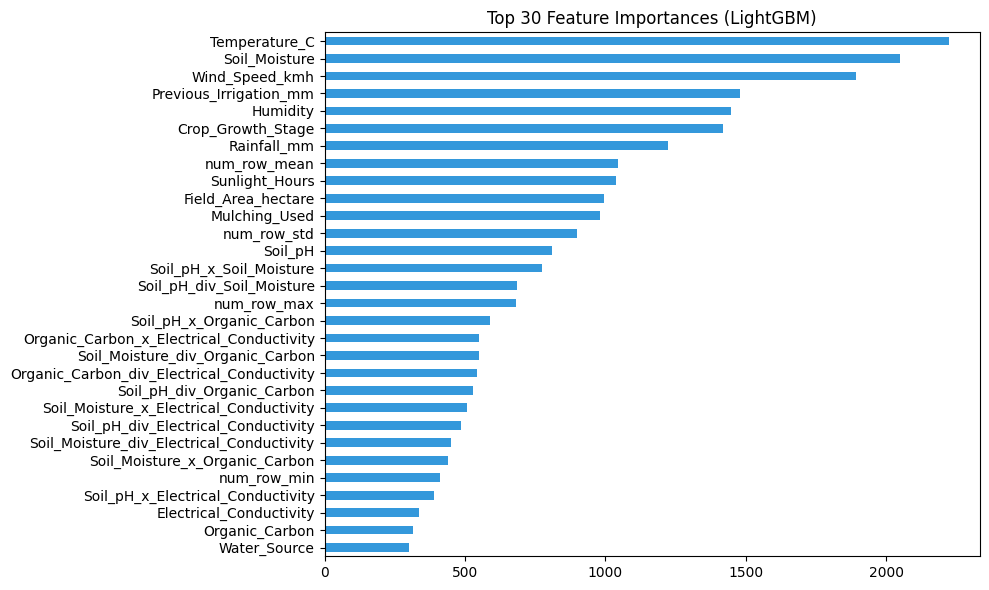

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
#  5. FEATURE SELECTION  (LightGBM importance)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  5. FEATURE SELECTION")
print("=" * 70)

_lgb_sel = lgb.LGBMClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, verbose=-1)
_lgb_sel.fit(X_fe, y)

fi = pd.Series(_lgb_sel.feature_importances_, index=X_fe.columns).sort_values(ascending=False)
threshold = fi.quantile(0.05)            # drop bottom 5%
selected_features = fi[fi > threshold].index.tolist()

print(f"Features before selection : {len(fi)}")
print(f"Features after  selection : {len(selected_features)}")

# Plot top-30 feature importances
plt.figure(figsize=(10, 6))
fi.head(30).sort_values().plot(kind="barh", color="#3498db")
plt.title("Top 30 Feature Importances (LightGBM)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

X = X_fe[selected_features].values
X_test = X_test_fe[selected_features].values

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
#  6. CROSS-VALIDATION HELPER
# ═══════════════════════════════════════════════════════════════════════════
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def cv_balanced_accuracy(model, X, y, use_smote=True):
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        if use_smote:
            sm = SMOTE(random_state=SEED)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        scores.append(balanced_accuracy_score(y_val, preds))

    mean, std = np.mean(scores), np.std(scores)
    return mean, std, scores


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
#  7. HYPERPARAMETER TUNING WITH OPTUNA  (Speed-Optimized)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  7. HYPERPARAMETER TUNING (Optuna — Fast Mode)")
print("=" * 70)
 
# ── Speed knobs ───────────────────────────────────────────────────────────
# 1. 3-fold CV during tuning (not 5)   → 40% fewer fits per trial
# 2. Cap trees at 200 during tuning    → final models use 3× more
# 3. Row-subsample inside each trial   → faster per-fit
# 4. MedianPruner kills bad trials early
# 5. 30 trials is enough for TPE to converge on tabular data
N_OPTUNA_FAST = 30
TUNE_FOLDS    = 3
TUNE_SAMPLE   = 15_000
 
skf_tune = StratifiedKFold(n_splits=TUNE_FOLDS, shuffle=True, random_state=SEED)
 
def fast_cv(model, use_smote=False):
    """Lightweight 3-fold CV on a row-capped sample — tuning only."""
    n = len(X)
    if n > TUNE_SAMPLE:
        idx = np.random.choice(n, TUNE_SAMPLE, replace=False)
        Xs, ys = X[idx], y[idx]
    else:
        Xs, ys = X, y
    scores = []
    for tr_i, val_i in skf_tune.split(Xs, ys):
        Xtr, Xval = Xs[tr_i], Xs[val_i]
        ytr, yval = ys[tr_i], ys[val_i]
        if use_smote:
            Xtr, ytr = SMOTE(random_state=SEED).fit_resample(Xtr, ytr)
        model.fit(Xtr, ytr)
        scores.append(balanced_accuracy_score(yval, model.predict(Xval)))
    return float(np.mean(scores))
 
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0)
 
# ── LightGBM ─────────────────────────────────────────────────────────────
def objective_lgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 100, 200),
        learning_rate    = trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        num_leaves       = trial.suggest_int("num_leaves", 20, 150),
        max_depth        = trial.suggest_int("max_depth", 3, 10),
        min_child_samples= trial.suggest_int("min_child_samples", 20, 100),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-6, 5.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
        class_weight="balanced", random_state=SEED, n_jobs=-1, verbose=-1
    )
    return fast_cv(lgb.LGBMClassifier(**params))
 
study_lgb = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=SEED),
                                 pruner=pruner)
study_lgb.optimize(objective_lgb, n_trials=N_OPTUNA_FAST, show_progress_bar=True)
# Scale up trees for the final model (tuning used a capped budget)
best_lgb_params = {**study_lgb.best_params,
                   "n_estimators": min(study_lgb.best_params["n_estimators"] * 3, 800)}
print(f"\nLGB best BA (tune): {study_lgb.best_value:.4f}")
 
# ── XGBoost ──────────────────────────────────────────────────────────────
def objective_xgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 100, 200),
        learning_rate    = trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        max_depth        = trial.suggest_int("max_depth", 3, 8),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma            = trial.suggest_float("gamma", 0, 3),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-6, 5.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
        use_label_encoder=False, eval_metric="mlogloss",
        random_state=SEED, n_jobs=-1
    )
    return fast_cv(xgb.XGBClassifier(**params))
 
study_xgb = optuna.create_study(direction="maximize",
                                  sampler=optuna.samplers.TPESampler(seed=SEED),
                                  pruner=pruner)
study_xgb.optimize(objective_xgb, n_trials=N_OPTUNA_FAST, show_progress_bar=True)
best_xgb_params = {**study_xgb.best_params,
                   "n_estimators": min(study_xgb.best_params["n_estimators"] * 3, 800)}
print(f"XGB best BA (tune): {study_xgb.best_value:.4f}")
 
# ── CatBoost ─────────────────────────────────────────────────────────────
def objective_cat(trial):
    params = dict(
        iterations    = trial.suggest_int("iterations", 100, 200),
        learning_rate = trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        depth         = trial.suggest_int("depth", 3, 8),
        l2_leaf_reg   = trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        bagging_temperature = trial.suggest_float("bagging_temperature", 0, 1),
        auto_class_weights="Balanced", random_seed=SEED, verbose=0
    )
    return fast_cv(cb.CatBoostClassifier(**params))
 
study_cat = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=SEED),
                                 pruner=pruner)
study_cat.optimize(objective_cat, n_trials=N_OPTUNA_FAST, show_progress_bar=True)
best_cat_params = {**study_cat.best_params,
                   "iterations": min(study_cat.best_params["iterations"] * 3, 800)}
print(f"CAT best BA (tune): {study_cat.best_value:.4f}")
 
print("\n Tuning done — final models use 3× more trees than tuning budget.")


  7. HYPERPARAMETER TUNING (Optuna — Fast Mode)


  0%|          | 0/30 [00:00<?, ?it/s]


LGB best BA (tune): 0.9625


  0%|          | 0/30 [00:00<?, ?it/s]

XGB best BA (tune): 0.9538


  0%|          | 0/30 [00:00<?, ?it/s]

CAT best BA (tune): 0.9682

 Tuning done — final models use 3× more trees than tuning budget.


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  8. SINGLE FOLD LOOP  — trains all models, builds OOF + test probas
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  8. OOF GENERATION — single shared fold loop")
print("=" * 70)
 
# ── Final model definitions ───────────────────────────────────────────────
final_models = {
    "CatBoost":    cb.CatBoostClassifier(
                       **best_cat_params,
                       auto_class_weights="Balanced",
                       random_seed=SEED, verbose=0),
 
 

}
 
model_keys = list(final_models.keys())
n_classes  = len(np.unique(y))
 
# Storage
oof_probas  = {k: np.zeros((len(X), n_classes))      for k in model_keys}
oof_labels  = {k: np.zeros(len(X), dtype=int)         for k in model_keys}
test_probas = {k: np.zeros((len(X_test), n_classes))  for k in model_keys}
 
# ── Parallel fold loop — all models trained simultaneously per fold ───────
from joblib import Parallel, delayed
import sklearn.base as skbase
 
def _fit_one(name, model, X_tr_s, y_tr_s, X_val, X_test, n_folds):
    """Fit one model on one fold. Fully stateless — safe for parallel."""
    m = skbase.clone(model)
    m.fit(X_tr_s, y_tr_s)
    return (
        name,
        m.predict_proba(X_val),              # oof probas
        np.array(m.predict(X_val)).ravel(),  # oof labels  (n,1) → (n,)
        m.predict_proba(X_test) / n_folds    # test probas (fold share)
    )
 
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"  Fold {fold+1}/{N_FOLDS} ...", end=" ", flush=True)
 
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
 
    # SMOTE once per fold — shared across all models
    X_tr_s, y_tr_s = SMOTE(random_state=SEED).fit_resample(X_tr, y_tr)
 
    # All 5 models fit in parallel within this fold
    # prefer="threads" works well since sklearn/lgbm/xgb release the GIL
    fold_out = Parallel(n_jobs=-1, prefer="threads")(
        delayed(_fit_one)(name, model, X_tr_s, y_tr_s, X_val, X_test, N_FOLDS)
        for name, model in final_models.items()
    )
 
    for name, oof_p, oof_l, test_p in fold_out:
        oof_probas[name][val_idx] = oof_p
        oof_labels[name][val_idx] = oof_l
        test_probas[name]        += test_p
 
    print("done")
 
# ── Per-model scores ──────────────────────────────────────────────────────
print("\n  Per-model OOF Balanced Accuracy:")
results = {}
for name in model_keys:
    ba = balanced_accuracy_score(y, oof_labels[name])
    results[name] = ba
    print(f"  {name:20s}  BA = {ba:.4f}")
 
best_single = max(results, key=results.get)
print(f"\n   Best single model : {best_single}  ({results[best_single]:.4f})")


  8. OOF GENERATION — single shared fold loop
  Fold 1/5 ... done
  Fold 2/5 ... done
  Fold 3/5 ... done
  Fold 4/5 ... done
  Fold 5/5 ... done

  Per-model OOF Balanced Accuracy:
  CatBoost              BA = 0.9642

   Best single model : CatBoost  (0.9642)


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  9. ENSEMBLE  — pure proba averaging, zero extra fits
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  9. ENSEMBLE  (reuses OOF probas — no extra fits)")
print("=" * 70)
 
# ── Strategy A : Simple average ───────────────────────────────────────────
avg_proba = np.mean([oof_probas[k] for k in model_keys], axis=0)
avg_preds = avg_proba.argmax(axis=1)
avg_ba    = balanced_accuracy_score(y, avg_preds)
print(f"  Simple Average           BA = {avg_ba:.4f}")
 
# ── Strategy B : Weighted average (weight ∝ individual BA) ───────────────
weights   = np.array([results[k] for k in model_keys])
weights   = weights / weights.sum()
wt_proba  = sum(w * oof_probas[k] for w, k in zip(weights, model_keys))
wt_preds  = wt_proba.argmax(axis=1)
wt_ba     = balanced_accuracy_score(y, wt_preds)
print(f"  Weighted Average         BA = {wt_ba:.4f}")
 
# ── Strategy C : Top-3 models only ───────────────────────────────────────
top3      = sorted(results, key=results.get, reverse=True)[:3]
t3_proba  = np.mean([oof_probas[k] for k in top3], axis=0)
t3_preds  = t3_proba.argmax(axis=1)
t3_ba     = balanced_accuracy_score(y, t3_preds)
print(f"  Top-3 Average            BA = {t3_ba:.4f}   models: {top3}")
 
# ── Pick best ─────────────────────────────────────────────────────────────
all_scores   = {**results,
                "SimpleAvg":   avg_ba,
                "WeightedAvg": wt_ba,
                "Top3Avg":     t3_ba}
overall_best = max(all_scores, key=all_scores.get)
print(f"\n  Overall best : {overall_best}  BA = {all_scores[overall_best]:.4f}")
 
# ── Map winner → test probas & OOF preds ─────────────────────────────────
if overall_best == "SimpleAvg":
    best_test_proba = np.mean([test_probas[k] for k in model_keys], axis=0)
    best_oof_preds  = avg_preds
elif overall_best == "WeightedAvg":
    best_test_proba = sum(w * test_probas[k] for w, k in zip(weights, model_keys))
    best_oof_preds  = wt_preds
elif overall_best == "Top3Avg":
    best_test_proba = np.mean([test_probas[k] for k in top3], axis=0)
    best_oof_preds  = t3_preds
else:                                        # a single model won
    best_test_proba = test_probas[overall_best]
    best_oof_preds  = oof_labels[overall_best]


  9. ENSEMBLE  (reuses OOF probas — no extra fits)
  Simple Average           BA = 0.9642
  Weighted Average         BA = 0.9642
  Top-3 Average            BA = 0.9642   models: ['CatBoost']

  Overall best : CatBoost  BA = 0.9642



  10. EVALUATION
              precision    recall  f1-score   support

        High       0.94      0.93      0.93     21009
         Low       0.99      0.99      0.99    369917
      Medium       0.99      0.97      0.98    239074

    accuracy                           0.98    630000
   macro avg       0.97      0.96      0.97    630000
weighted avg       0.98      0.98      0.98    630000



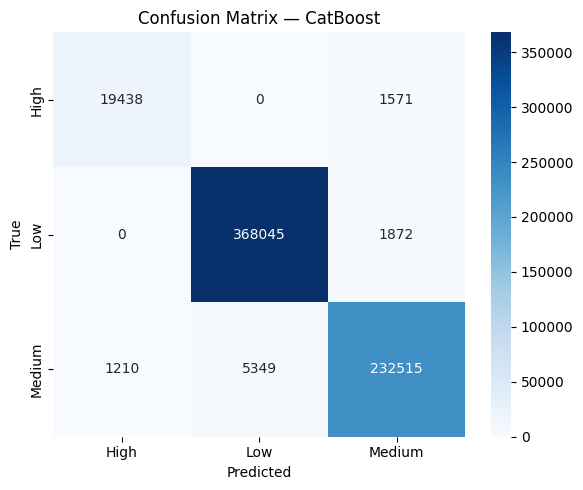


  OOF Balanced Accuracy : 0.9642


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
#  10. EVALUATION  — confusion matrix + report (uses OOF preds, no refit)
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  10. EVALUATION")
print("=" * 70)
 
print(classification_report(y, best_oof_preds, target_names=le_target.classes_))
 
cm = confusion_matrix(y, best_oof_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title(f"Confusion Matrix — {overall_best}")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()
 
oof_ba = balanced_accuracy_score(y, best_oof_preds)
print(f"\n  OOF Balanced Accuracy : {oof_ba:.4f}")

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
#  11. SUBMISSION  — exact format: id,Irrigation_Need
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  11. SUBMISSION")
print("=" * 70)
 
# Step 1: decode numeric predictions → original string labels (Low/Medium/High)
test_preds_labels = le_target.inverse_transform(
    best_test_proba.argmax(axis=1)
)
 
# Step 2: make sure id column is clean integer (no floats, no index bleed)
ids_clean = test_ids.reset_index(drop=True).astype(int)
 
# Step 3: build submission with EXACT required columns
submission = pd.DataFrame({
    "id":             ids_clean,
    "Irrigation_Need": test_preds_labels
})
 
# Step 4: sort by id ascending (matches expected submission order)
submission = submission.sort_values("id").reset_index(drop=True)
 
# Step 5: validate before saving
assert list(submission.columns) == ["id", "Irrigation_Need"], "Column mismatch!"
assert submission["Irrigation_Need"].isin(["Low", "Medium", "High"]).all(), \
    f"Unknown labels found: {submission['Irrigation_Need'].unique()}"
assert submission["id"].duplicated().sum() == 0, "Duplicate IDs found!"
assert submission.isnull().sum().sum() == 0, "NaN values in submission!"
 
# Step 6: save
submission.to_csv(OUTPUT_PATH, index=False)
 
# Step 7: verify the saved file looks exactly right
saved = pd.read_csv(OUTPUT_PATH)
print(f"\n  Saved → {OUTPUT_PATH}")
print(f"  Rows  : {len(saved)}")
print(f"  Cols  : {list(saved.columns)}")
print(f"\n  Label distribution:")
print(saved["Irrigation_Need"].value_counts().to_string())
print(f"\n  Sample (first 5 rows):")
print(saved.head(5).to_string(index=False))
 
print("\n" + "=" * 70)
print("  PIPELINE COMPLETE")
print(f"  OOF Balanced Accuracy : {oof_ba:.4f}")
print(f"  Model                 : CatBoost")
print(f"  Output                : {OUTPUT_PATH}")
print("=" * 70)


  11. SUBMISSION

  Saved → /kaggle/working/submission.csv
  Rows  : 270000
  Cols  : ['id', 'Irrigation_Need']

  Label distribution:
Irrigation_Need
Low       159842
Medium    101240
High        8918

  Sample (first 5 rows):
    id Irrigation_Need
630000             Low
630001             Low
630002             Low
630003             Low
630004             Low

  PIPELINE COMPLETE
  OOF Balanced Accuracy : 0.9642
  Model                 : CatBoost
  Output                : /kaggle/working/submission.csv
